### Film Öneri Sistemi

Gerçek bir veri seti üzerinden film öneri sistemi geliştirmek.



1.   İzleyici-film puan matrisi
2.   İçerik tabanlı filtreleme (Content Based Filtering)uygulayacağız
3.   İşbirlikçi filtreleme (Collaborative Filtering) uygulayacağız - Kullanıcıların geçmiş izlemelerini analiz ederek benzer kullanıcıların tespiti ve geçmişte benzer şeyleri beğenen kullanıcılara birbirlerinin izledikleri yayınları önerme.
4.   Kosinüs benzerliği kullanarak kullanıcı bazlı önerilerde bulunacağız.
5.   Bu yayını izleyenler şu yayınları da izledi mantığını kodlayacağız.


### 1. Kütüphanelerin yüklenmesi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity # benzerliği ölçmek için
from sklearn.preprocessing import MinMaxScaler # ölçeklendirici
import zipfile, io, urllib.request
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)

### 2. Gerçek Veri seti (MovieLens)
**MovieLens Small Dataset** — GroupLens tarafından toplanan gerçek film değerlendirmeleri. 100.000+ değerlendirme, 600+ kullanıcı, 9.000+ film.

**Kaynak:** [MovieLens](https://grouplens.org/datasets/movielens/) | [Kaggle](https://www.kaggle.com/datasets/grouplens/movielens-20m-dataset)

In [ ]:
# gerçek veri setini çekelim
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

In [ ]:
# çekme isteği oluştur
resp=urllib.request.urlopen(url)
# dosyayı al
z=zipfile.ZipFile(io.BytesIO(resp.read()))

In [ ]:
# zip dosyasını aç ve pandas ile oku
# filmler hakkında bilgi
df_movies=pd.read_csv(z.open('ml-latest-small/movies.csv'))
# filmlere verilen puanlar
df_ratings=pd.read_csv(z.open('ml-latest-small/ratings.csv'))

Metinde bahsi geçen CSV dosyalarının içerikleri ve yapıları kısaca şu şekildedir:

* **`movies.csv`**: Filmlerin temel bilgilerini barındırır.
* *Şema:* `movieId, title, genres`
* *Not:* Film adları parantez içinde çıkış yılını içerir; türler (`genres`) ise `|` (pipe) karakteri ile ayrılmış bir listedir (örn. `Action|Adventure`).


* **`ratings.csv`**: Kullanıcıların filmlere verdiği puanları içerir.
* *Şema:* `userId, movieId, rating, timestamp`
* *Not:* Puanlar 0.5 ile 5.0 arasındadır. Zaman damgası UTC formatındadır.


* **`tags.csv`**: Kullanıcılar tarafından filmlere eklenen serbest metin etiketleridir.
* *Şema:* `userId, movieId, tag, timestamp`
* *Not:* Etiketler kullanıcı yapımı kelime veya kısa ifadelerden oluşur.


* **`links.csv`**: MovieLens veri setindeki filmleri diğer harici film platformlarıyla eşleştirmek için kullanılan ID'leri içerir.
* *Şema:* `movieId, imdbId, tmdbId`
* *Not:* IMDb ve The Movie Database (TMDb) bağlantılarını kurmayı sağlar.


* **`genome-scores.csv`**: Filmlerin belirli etiket özelliklerini ne kadar güçlü yansıttığını gösteren yoğun matris verisidir.
* *Şema:* `movieId, tagId, relevance`
* *Not:* Makine öğrenmesi algoritmasıyla hesaplanmış alaka düzeyini (`relevance`) gösterir.


* **`genome-tags.csv`**: `genome-scores.csv` dosyasındaki etiket ID'lerinin metinsel açıklamalarını içerir.
* *Şema:* `tagId, tag`



**Genel Biçim Özellikleri:** Tüm dosyalar `UTF-8` kodlamasına sahiptir, ilk satırları başlık (`header`) bilgisidir ve virgülle ayrılmış değerlerden oluşur. `userId` ve `movieId` değerleri tüm dosyalarda tutarlıdır, ilişkisel bir yapı sunar.

In [ ]:
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
df_movies.info() # 9742 film

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [ ]:
df_ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
df_ratings.info() # 100.836

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [ ]:
df_ratings['userId'].value_counts()
# Toplam 610 kullanıcı var. en çok puanlama yapan 2698 film puanlamış

,count
userId,
414,2698
599,2478
474,2108
448,1864
274,1346
...,...
442,20
278,20
147,20


In [ ]:
# Kullanıcılar tarafından Oyuncak hikayesine verilen puanlar
df_ratings[df_ratings['movieId']==1]

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
516,5,1,4.0,847434962
874,7,1,4.5,1106635946
1434,15,1,2.5,1510577970
1667,17,1,4.5,1305696483
...,...,...,...,...
97364,606,1,2.5,1349082950
98479,607,1,4.0,964744033
98666,608,1,2.5,1117408267
99497,609,1,3.0,847221025


In [ ]:
# Oyuncak hikayesinin (1995) rating ortalaması
df_ratings[df_ratings['movieId']==1]['rating'].mean()

np.float64(3.9209302325581397)

In [ ]:
# Ortak Alanı kullanarak iki veri setini birleştirelim
df=df_ratings.merge(df_movies, how='left', on='movieId')
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
# veri setini incele
# Kaç puanlama var
# Kaç film var
# Toplam kullanıcı

In [ ]:
print("Puanlama sayısı",len(df))
print("Film sayısı", df['movieId'].nunique())
print ("Kullanıcı sayısı", df['userId'].nunique())

Puanlama sayısı 100836
Film sayısı 9724
Kullanıcı sayısı 610


In [ ]:
# rating dağılımı
print(df['rating'].value_counts())

rating
4.0    26818
3.0    20047
5.0    13211
3.5    13136
4.5     8551
2.0     7551
2.5     5550
1.0     2811
1.5     1791
0.5     1370
Name: count, dtype: int64


In [ ]:
df['rating'].value_counts().sort_index()

,count
rating,
0.5,1370
1.0,2811
1.5,1791
2.0,7551
2.5,5550
3.0,20047
3.5,13136
4.0,26818
4.5,8551


<Axes: xlabel='rating'>

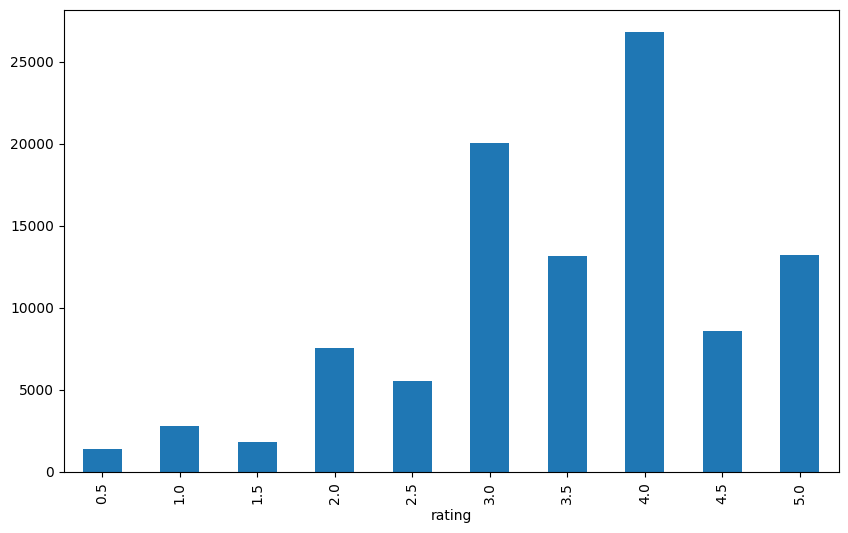

In [ ]:
df['rating'].value_counts().sort_index().plot(kind='bar')

In [ ]:
# veri setindeki tüm ratinglerin ortalaması
df['rating'].mean()

np.float64(3.501556983616962)

In [ ]:
# ratingi en yüksek 10 film
df.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)

,rating
title,
Karlson Returns (1970),5.0
Zeitgeist: Moving Forward (2011),5.0
"Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)",5.0
Dragons: Gift of the Night Fury (2011),5.0
12 Angry Men (1997),5.0
Justice League: Doom (2012),5.0
Junior and Karlson (1968),5.0
Jump In! (2007),5.0
"Human Condition III, The (Ningen no joken III) (1961)",5.0


In [ ]:
# tamam ratingi en yüksek filmleri aldık ama 1 tane 5 puan alanda ilk sırada olabilir
# ortalama ve puan veren kişi sayısı
movie_stats=df.groupby('title')['rating'].agg(mean='mean', count='count')

# en az 100 kişi tarafından oylanan filmleri alalım
top_movies=movie_stats[movie_stats['count']>100]
top_movies.sort_values(by='mean', ascending=False).head(20)

,mean,count
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126
"Dark Knight, The (2008)",4.238255,149
"Usual Suspects, The (1995)",4.237745,204
"Princess Bride, The (1987)",4.232394,142


In [ ]:
len(df[df['title']=='Karlson Returns (1970)'])

1

In [ ]:
df[df['title'].str.contains('Karlson')].head()

,userId,movieId,rating,timestamp,title,genres
16907,105,166183,5.0,1526208038,Junior and Karlson (1968),Adventure|Animation|Children
16916,105,172585,5.0,1526207575,Karlson Returns (1970),Adventure|Animation|Children


### Öneri Sistemi

Kullanıcı-ürün matrisi ve benzerlik hesabı ile öneri sistemi kuruyoruz. Cosine benzerliği, iki vektör arasındaki açıya dayalı bir benzerlik ölçüsüdür.

1. Veriyi Hazırlama (Mutfak Hazırlığı)
İlk olarak MovieLens adındaki devasa bir kütüphaneden yaklaşık 100.000 film puanını aldık.

Nasıl Yapıldı?: pandas kütüphanesi ile kullanıcıların hangi filme kaç puan verdiğini ve o filmin türlerini içeren tabloları birleştirdik.
Pivot Tablo: 'Hangi kullanıcı, hangi filme ne puan verdi?' sorusunun cevabı olan dev bir matris (satırlarda kullanıcılar, sütunlarda filmler) oluşturduk.

In [ ]:
# kullanıcı-film puan matrisi hazırlama (pivot)
# en çok değerlendirilen ilk 500 filmi seç
popular_movies=df['movieId'].value_counts().head(500)
popular_movies

,count
movieId,
356,329
318,317
296,307
593,279
2571,278
...,...
802,46
1884,46
2076,46


In [ ]:
popular_movies=popular_movies=df['movieId'].value_counts().head(500).index # en çok oylanan filmlerin indexlerini aldık
popular_movies

Index([  356,   318,   296,   593,  2571,   260,   480,   110,   589,   527,
       ...
        1994,   112,  1396,  5060, 64614,   802,  1884,  2076,  2002,    44],
      dtype='int64', name='movieId', length=500)

In [ ]:
# popüler film listesini öneri olarak sunabiliriz
df_popular=df[df['movieId'].isin(popular_movies)]
df_popular

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
...,...,...,...,...,...,...
100673,610,109487,3.5,1493845041,Interstellar (2014),Sci-Fi|IMAX
100701,610,112852,4.5,1493845402,Guardians of the Galaxy (2014),Action|Adventure|Sci-Fi
100737,610,122882,5.0,1493845444,Mad Max: Fury Road (2015),Action|Adventure|Sci-Fi|Thriller
100742,610,122904,3.0,1493845981,Deadpool (2016),Action|Adventure|Comedy|Sci-Fi


In [ ]:
# index userid, sütunlar film adi hücreler de rating
user_movie_matrix=df_popular.pivot_table(index='userId',
                                         columns='title',
                                         values='rating')
user_movie_matrix

title,10 Things I Hate About You (1999),101 Dalmatians (1996),12 Angry Men (1957),2001: A Space Odyssey (1968),28 Days Later (2002),300 (2007),"40-Year-Old Virgin, The (2005)",50 First Dates (2004),A.I. Artificial Intelligence (2001),"Abyss, The (1989)",...,Willy Wonka & the Chocolate Factory (1971),"Wizard of Oz, The (1939)","Wolf of Wall Street, The (2013)",X-Men (2000),X-Men: The Last Stand (2006),X2: X-Men United (2003),You've Got Mail (1998),Young Frankenstein (1974),Zombieland (2009),Zoolander (2001)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,5.0,5.0,NaN,5.0,NaN,NaN,NaN,5.0,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN
4,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,3.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.5,3.5,NaN,NaN
607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN
608,NaN,NaN,NaN,3.0,3.5,5.0,NaN,NaN,4.5,3.0,...,3.5,2.5,NaN,4.0,4.0,4.0,NaN,NaN,NaN,3.0


In [ ]:
user_movie_matrix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 607 entries, 1 to 610
Columns: 500 entries, 10 Things I Hate About You (1999) to Zoolander (2001)
dtypes: float64(500)
memory usage: 2.3 MB


In [ ]:
# veri setinin doluluk oranı
user_movie_matrix.notna().sum().sum()/user_movie_matrix.size
# %14 ü dolu

np.float64(0.14409884678747942)

İçerik Tabanlı Filtreleme (Content-Based Filtering)

Filmlerin tür özelliklerine göre benzerlik hesaplıyoruz. Eğer bir kullanıcı bir filmi beğendiyse, benzer türdeki filmler önerilir.

2. İçerik Tabanlı Öneri (Tür Benzerliği)
'Eğer Aksiyon ve Bilim Kurgu seviyorsan, sana başka bir Aksiyon ve Bilim Kurgu filmi önerelim' mantığıdır.

Nasıl Yapıldı?: Filmlerin türlerini (Komedi, Korku vb.) bilgisayarın anlayacağı 0 ve 1 sayılarına dönüştürdük.
Kosinüs Benzerliği: Bu sayısal veriler arasındaki 'açıyı' hesapladık. Açı ne kadar darsa (1.00'e yakınsa), filmler tür olarak o kadar benzerdir.

In [ ]:
# türleri sayısallaştır
films_df=df_movies[df_movies['movieId'].isin(popular_movies)].set_index('title')
films_df

,movieId,genres
title,,
Toy Story (1995),1,Adventure|Animation|Children|Comedy|Fantasy
Jumanji (1995),2,Adventure|Children|Fantasy
Grumpier Old Men (1995),3,Comedy|Romance
Father of the Bride Part II (1995),5,Comedy
Heat (1995),6,Action|Crime|Thriller
...,...,...
Guardians of the Galaxy (2014),112852,Action|Adventure|Sci-Fi
The Imitation Game (2014),116797,Drama|Thriller|War
Mad Max: Fury Road (2015),122882,Action|Adventure|Sci-Fi|Thriller


In [ ]:
# türleri sayısallaştır
genres_split=films_df['genres'].str.get_dummies('|')
genres_split

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
title,,,,,,,,,,,,,,,,,,,
Toy Story (1995),0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
Jumanji (1995),0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
Grumpier Old Men (1995),0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Heat (1995),1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Guardians of the Galaxy (2014),1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
The Imitation Game (2014),0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0
Mad Max: Fury Road (2015),1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0


In [ ]:
genres_split.columns

Index(['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX',
       'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western'],
      dtype='object')

In [ ]:
genre_matrix=genres_split.loc[films_df.index]
film_names=films_df.index
film_names

Index(['Toy Story (1995)', 'Jumanji (1995)', 'Grumpier Old Men (1995)',
       'Father of the Bride Part II (1995)', 'Heat (1995)', 'Sabrina (1995)',
       'GoldenEye (1995)', 'American President, The (1995)', 'Casino (1995)',
       'Sense and Sensibility (1995)',
       ...
       'Skyfall (2012)', 'Django Unchained (2012)',
       'Wolf of Wall Street, The (2013)', 'Grand Budapest Hotel, The (2014)',
       'Interstellar (2014)', 'Guardians of the Galaxy (2014)',
       'The Imitation Game (2014)', 'Mad Max: Fury Road (2015)',
       'Deadpool (2016)', 'The Martian (2015)'],
      dtype='object', name='title', length=500)

In [ ]:
len(film_names)

500

In [ ]:
# filmler arası benzerlik hesaplaması
film_similarity=cosine_similarity(genre_matrix)
film_sim_df=pd.DataFrame(film_similarity, index=film_names, columns=film_names)
film_sim_df

title,Toy Story (1995),Jumanji (1995),Grumpier Old Men (1995),Father of the Bride Part II (1995),Heat (1995),Sabrina (1995),GoldenEye (1995),"American President, The (1995)",Casino (1995),Sense and Sensibility (1995),...,Skyfall (2012),Django Unchained (2012),"Wolf of Wall Street, The (2013)","Grand Budapest Hotel, The (2014)",Interstellar (2014),Guardians of the Galaxy (2014),The Imitation Game (2014),Mad Max: Fury Road (2015),Deadpool (2016),The Martian (2015)
title,,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),1.000000,0.774597,0.316228,0.447214,0.000000,0.316228,0.258199,0.258199,0.000000,0.000000,...,0.223607,0.000000,0.258199,0.316228,0.000000,0.258199,0.000000,0.223607,0.447214,0.258199
Jumanji (1995),0.774597,1.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,...,0.288675,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.288675,0.288675,0.333333
Grumpier Old Men (1995),0.316228,0.000000,1.000000,0.707107,0.000000,1.000000,0.000000,0.816497,0.000000,0.500000,...,0.000000,0.000000,0.408248,0.500000,0.000000,0.000000,0.000000,0.000000,0.353553,0.000000
Father of the Bride Part II (1995),0.447214,0.000000,0.707107,1.000000,0.000000,0.707107,0.000000,0.577350,0.000000,0.000000,...,0.000000,0.000000,0.577350,0.707107,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
Heat (1995),0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.666667,0.000000,0.408248,0.000000,...,0.577350,0.333333,0.333333,0.000000,0.000000,0.333333,0.333333,0.577350,0.288675,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Guardians of the Galaxy (2014),0.258199,0.333333,0.000000,0.000000,0.333333,0.000000,0.666667,0.000000,0.000000,0.000000,...,0.577350,0.333333,0.000000,0.000000,0.408248,1.000000,0.000000,0.866025,0.866025,0.666667
The Imitation Game (2014),0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.333333,0.333333,0.408248,0.408248,...,0.288675,0.333333,0.333333,0.408248,0.000000,0.000000,1.000000,0.288675,0.000000,0.333333
Mad Max: Fury Road (2015),0.223607,0.288675,0.000000,0.000000,0.577350,0.000000,0.866025,0.000000,0.000000,0.000000,...,0.750000,0.288675,0.000000,0.000000,0.353553,0.866025,0.288675,1.000000,0.750000,0.577350


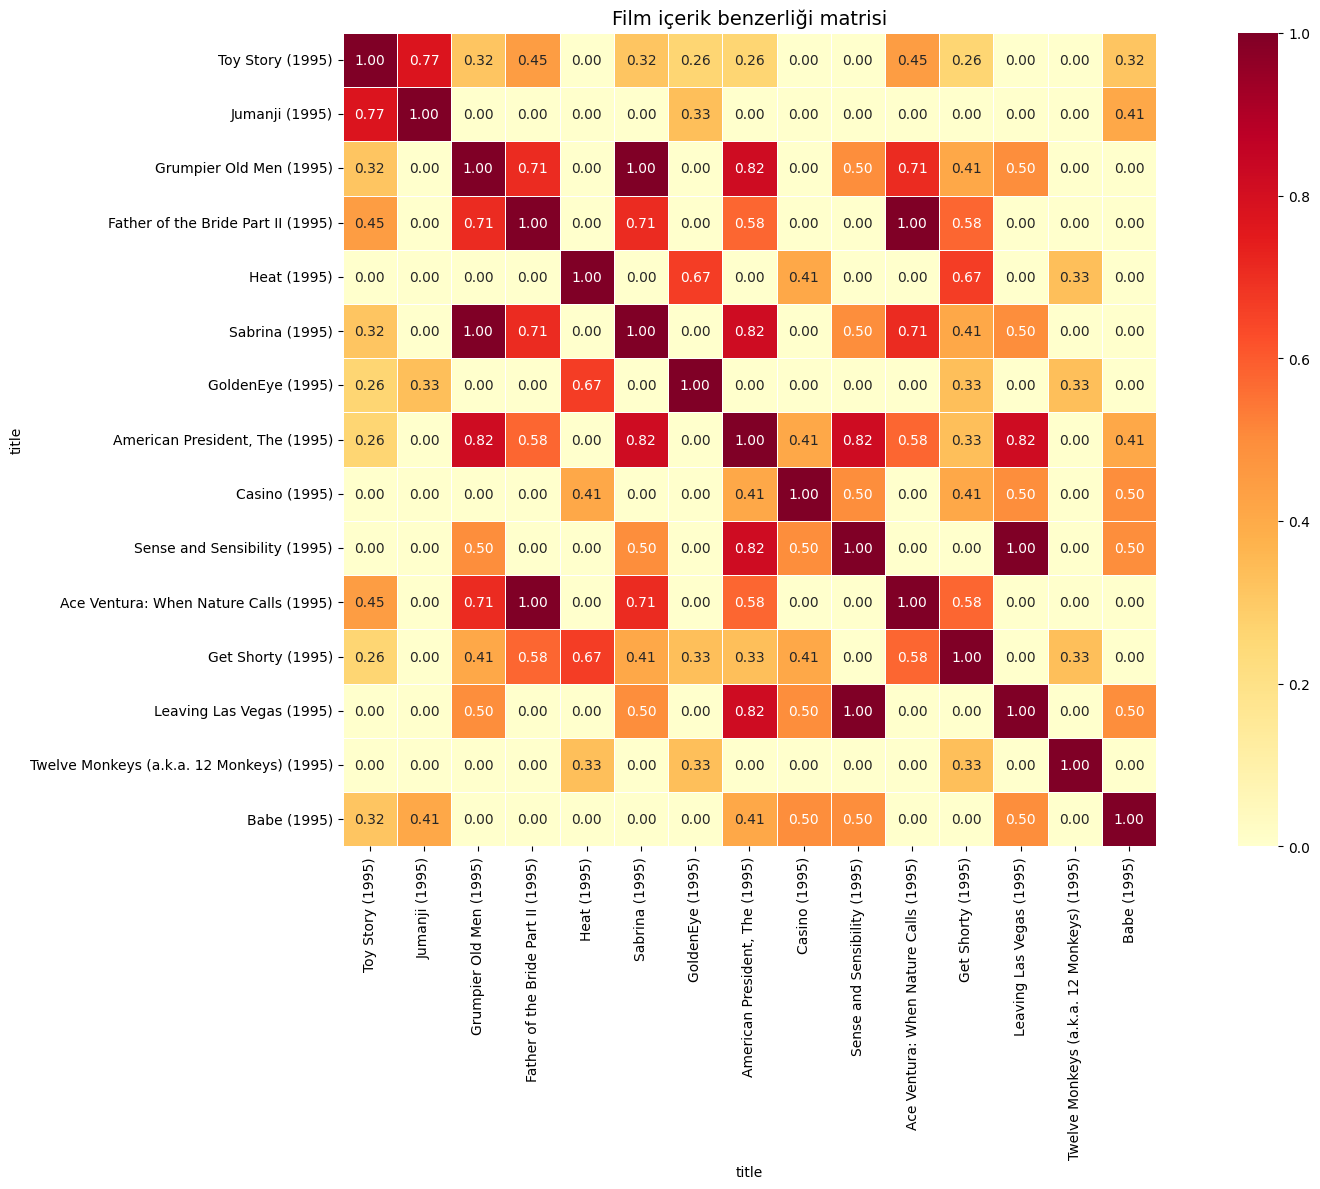

In [ ]:
# heat map
plt.figure(figsize=(18,12))
sns.heatmap(film_sim_df.iloc[:15,:15],
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            square=True,
            linewidths=.5)
plt.title("Film içerik benzerliği matrisi", fontsize=14)
plt.tight_layout()
plt.show()

Veri Gruplama ve Analiz

Sql deki gibi gruplama ve özet istatistikler hesaplanabilir.

İçerik Tabanlı Öneriler

In [ ]:
def content_based_recommend(movie_name,n=10):
    """
    Bu fonksiyon verdiğmiz filme içerik türü olarak en yakın n sayıda filmi listeler.
    """
    if movie_name not in film_sim_df.index:
        print(f"'{movie_name}' bulunamadı!")
        return None

    similarities=film_sim_df[movie_name].drop(movie_name).sort_values(ascending=False)
    top_n=similarities.head(n)
    return top_n

In [ ]:
content_based_recommend('Toy Story (1995)')

,Toy Story (1995)
title,
"Monsters, Inc. (2001)",1.000000
Toy Story 2 (1999),1.000000
Toy Story 3 (2010),0.912871
Shrek (2001),0.912871
Space Jam (1996),0.912871
Ice Age (2002),0.894427
"Bug's Life, A (1998)",0.894427
Finding Nemo (2003),0.894427
Who Framed Roger Rabbit? (1988),0.845154


In [ ]:
film_sim_df.index

In [ ]:
content_based_recommend('Deadpool (2016)')

,Deadpool (2016)
title,
"Fifth Element, The (1997)",1.000000
Star Wars: Episode IV - A New Hope (1977),0.866025
Back to the Future Part II (1989),0.866025
Iron Man (2008),0.866025
Star Wars: Episode I - The Phantom Menace (1999),0.866025
Superman (1978),0.866025
Waterworld (1995),0.866025
Stargate (1994),0.866025
Star Wars: Episode III - Revenge of the Sith (2005),0.866025


In [ ]:
content_based_recommend("Guardians of the Galaxy (2014)")

,Guardians of the Galaxy (2014)
title,
Iron Man (2008),1.0
Stargate (1994),1.0
Waterworld (1995),1.0
Serenity (2005),1.0
Star Wars: Episode IV - A New Hope (1977),1.0
Demolition Man (1993),1.0
Star Wars: Episode III - Revenge of the Sith (2005),1.0
Star Wars: Episode I - The Phantom Menace (1999),1.0
Star Wars: Episode VI - Return of the Jedi (1983),1.0


In [ ]:
content_based_recommend('Interstellar (2014)')

,Interstellar (2014)
title,
Star Trek (2009),0.707107
Avatar (2009),0.707107
Spider-Man 2 (2004),0.707107
Star Wars: Episode II - Attack of the Clones (2002),0.707107
V for Vendetta (2006),0.707107
"Avengers, The (2012)",0.707107
"Matrix Revolutions, The (2003)",0.632456
I Am Legend (2007),0.632456
"Matrix Reloaded, The (2003)",0.632456


In [ ]:
movie=input("Türünü beğendiğiniz filmin adını girin!")
#na boş satırları dikkate alma
results=df_popular[df_popular['title'].str.contains(movie, case=False, na=False)]
#arama sonucunu listele
unique_results=results['title'].unique()
if len(unique_results)<1:
    print("Bu sözcüğü içeren bir film listede yok.")
else:
    display(unique_results)

Türünü beğendiğiniz filmin adını girin!samurai


array(['Seven Samurai (Shichinin no samurai) (1954)',
       'Last Samurai, The (2003)'], dtype=object)

In [ ]:
movie_name=unique_results[1]
content_based_recommend(movie_name)

,"Last Samurai, The (2003)"
title,
Troy (2004),1.000000
Braveheart (1995),0.866025
Black Hawk Down (2001),0.866025
Inglourious Basterds (2009),0.866025
Saving Private Ryan (1998),0.866025
Apocalypse Now (1979),0.866025
"Patriot, The (2000)",0.866025
Seven Samurai (Shichinin no samurai) (1954),0.866025
Gladiator (2000),0.866025


#İçerik Tabanlı Öneri Sistemi Arayüzü

In [ ]:
pip install gradio

In [ ]:
import gradio as gr
gr.__version__

'6.20.0'

In [ ]:
def gr_recommend(movie_name, n=10):
    """
    Bu fonksiyon verdiğimiz filme içerik türü olarak en yakın n sayıda filmi listeler.
    """
    if movie_name not in film_sim_df.index:
        return None

    similarities = film_sim_df[movie_name].drop(movie_name).sort_values(ascending=False)
    top_n = similarities.head(n)

    # Gradio Dataframe bileşeni için Series'i DataFrame'e dönüştürüyoruz
    return top_n.reset_index().rename(columns={'index': 'Film Adı', movie_name: 'Benzerlik Skoru'})

# popüler film listesini gr arayüzden dd çekmek için hazırlayalım
popular_titles = sorted(film_sim_df.index.tolist())

interface = gr.Interface(
    fn=gr_recommend,
    inputs=[
        gr.Dropdown(choices=popular_titles,
                    label='Hangi Filmi Tercih edersiniz!',
                    info='Sadece 500 film arasından seçim yapılabilir!',
                    filterable=True), # Yazarak arama yapma özelliği eklendi
        gr.Slider(minimum=1,
                  maximum=20,
                  step=1,
                  value=10,
                  label="Öneri sayısı")
    ],
    outputs=gr.Dataframe(label="Öneriler",
                         row_count=20),
    title="İçerik Bazlı Film Öneri Sistemi",
    description="Türünü beğendiğiniz ve izlediğiniz bir filmi seçin."
)
interface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://2b8ecba9927b160b4f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://2b8ecba9927b160b4f.gradio.live


9. Hafta Ders 1-2 Ödev 1

In [ ]:
import gradio as gr
import pandas as pd

def get_styled_recommendations(movie_name, top_n=10):
    """
    Notebook'taki gr_recommend mantığına göre güncellenmiş öneri fonksiyonu.
    """
    try:
        if movie_name not in film_sim_df.index:
            return pd.DataFrame({"Hata": [f"'{movie_name}' bulunamadı."]})

        # Benzerlik skorlarını al
        similarities = film_sim_df[movie_name].drop(movie_name).sort_values(ascending=False)
        top_results = similarities.head(top_n)

        # DataFrame formatına dönüştür (Notebook snippet'lerindeki gibi)
        recommendations = top_results.reset_index()
        recommendations.columns = ['Film Adı', 'Benzerlik Oranı']

        # Görselleştirme için yüzde formatı
        recommendations['Benzerlik Oranı'] = recommendations['Benzerlik Oranı'].apply(lambda x: f"%{round(x*100, 1)}")

        return recommendations
    except Exception as e:
        return pd.DataFrame({"Sistem Hatası": [str(e)]})

# Arayüz Ayarları
popular_titles = sorted(film_sim_df.index.tolist())

with gr.Blocks() as demo:
    gr.Markdown("# 🎬 Profesyonel Film Öneri Asistanı")
    gr.Markdown("Notebook içerisindeki benzerlik matrisi kullanılarak optimize edilmiştir.")

    with gr.Row():
        with gr.Column(scale=1):
            movie_input = gr.Dropdown(
                choices=popular_titles,
                label="Favori Filminiz",
                info="Listeden bir film seçin veya aratın",
                filterable=True
            )
            n_slider = gr.Slider(
                minimum=1,
                maximum=20,
                value=10,
                step=1,
                label="Öneri Sayısı"
            )
            submit_btn = gr.Button("Önerileri Getir", variant="primary")

        with gr.Column(scale=2):
            output_table = gr.Dataframe(
                headers=["Film Adı", "Benzerlik Oranı"],
                label="Önerilen Benzer İçerikler",
                interactive=False
            )

    # Tetikleyiciler
    submit_btn.click(
        fn=get_styled_recommendations,
        inputs=[movie_input, n_slider],
        outputs=output_table
    )

# Temayı launch içinde vererek Gradio 6.0 uyumluluğu sağlıyoruz
demo.launch(share=True, debug=True, theme=gr.themes.Soft(primary_hue="blue"))

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://732e58fb4aca00a76e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### İşbirlikçi filtreleme iki ana yaklaşım

1. Kullanıcı Tabanlı : Benzer zevklere sahip izleyiciler bulunur. Senin gibi izleyiciler şunları da beğendi!
2. Öge Tabanlı : Benzer Puanlama örüntüsüne sahip filmler bulunur. Bu filmi beğenenler şunları da beğendi!

Ortak zevkler, ortak sevilen filmler. Film zevki size benzeyen insanlar neler izlemiş sorumuz bu. Bizm verdiğimiz puanların dizllimi ile diğer kulalnıcıların (600+) puanlarını karşılaştırıyoruz. Bu puanlama benzerliği en yüksek 5-10 izleyici bularak onların izleyip beğendiği ama bizim henüz izlemediğimiz filmler beğenme olasılığı yüksek olduğu için bize önerilir.

In [ ]:
ratings_filled=user_movie_matrix.fillna(0)
ratings_filled

title,10 Things I Hate About You (1999),101 Dalmatians (1996),12 Angry Men (1957),2001: A Space Odyssey (1968),28 Days Later (2002),300 (2007),"40-Year-Old Virgin, The (2005)",50 First Dates (2004),A.I. Artificial Intelligence (2001),"Abyss, The (1989)",...,Willy Wonka & the Chocolate Factory (1971),"Wizard of Oz, The (1939)","Wolf of Wall Street, The (2013)",X-Men (2000),X-Men: The Last Stand (2006),X2: X-Men United (2003),You've Got Mail (1998),Young Frankenstein (1974),Zombieland (2009),Zoolander (2001)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,5.0,5.0,0.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0
4,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,3.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.5,3.5,0.0,0.0
607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
608,0.0,0.0,0.0,3.0,3.5,5.0,0.0,0.0,4.5,3.0,...,3.5,2.5,0.0,4.0,4.0,4.0,0.0,0.0,0.0,3.0


In [ ]:
# kullanıcılar arası kosinüs benzerliği
user_similarity=cosine_similarity(ratings_filled)
user_similarity

array([[1.        , 0.0500123 , 0.13448567, ..., 0.4755423 , 0.15675369,
        0.33629946],
       [0.0500123 , 1.        , 0.        , ..., 0.08015854, 0.04587099,
        0.22318358],
       [0.13448567, 0.        , 1.        , ..., 0.08380949, 0.        ,
        0.01231081],
       ...,
       [0.4755423 , 0.08015854, 0.08380949, ..., 1.        , 0.21634   ,
        0.60230622],
       [0.15675369, 0.04587099, 0.        , ..., 0.21634   , 1.        ,
        0.13196771],
       [0.33629946, 0.22318358, 0.01231081, ..., 0.60230622, 0.13196771,
        1.        ]])

In [ ]:
user_sim_df=pd.DataFrame(user_similarity,index=user_movie_matrix.index,columns=user_movie_matrix.index)
user_sim_df

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.050012,0.134486,0.372457,0.206714,0.237698,0.251116,0.190091,0.131416,0.039044,...,0.124321,0.252199,0.479644,0.117965,0.270127,0.391714,0.408282,0.475542,0.156754,0.336299
2,0.050012,1.000000,0.000000,0.008010,0.026430,0.055054,0.016834,0.037578,0.000000,0.155010,...,0.310707,0.027829,0.033787,0.000000,0.000000,0.078839,0.023416,0.080159,0.045871,0.223184
3,0.134486,0.000000,1.000000,0.000000,0.028203,0.009064,0.000000,0.024059,0.000000,0.000000,...,0.015186,0.017817,0.010999,0.000000,0.078475,0.065110,0.023987,0.083809,0.000000,0.012311
4,0.372457,0.008010,0.000000,1.000000,0.120152,0.138838,0.193851,0.102497,0.027248,0.070373,...,0.155556,0.154371,0.492286,0.092102,0.175300,0.359125,0.241842,0.325224,0.042175,0.266444
5,0.206714,0.026430,0.028203,0.120152,1.000000,0.487914,0.129580,0.516777,0.000000,0.061462,...,0.091138,0.547331,0.185880,0.361087,0.270016,0.175284,0.241516,0.236104,0.379774,0.144090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,0.391714,0.078839,0.065110,0.359125,0.175284,0.200919,0.433049,0.193721,0.187633,0.225908,...,0.393244,0.238205,0.556911,0.145687,0.333795,1.000000,0.317418,0.605936,0.142981,0.571898
607,0.408282,0.023416,0.023987,0.241842,0.241516,0.287897,0.286382,0.253495,0.023895,0.023855,...,0.140877,0.309644,0.437712,0.199545,0.227064,0.317418,1.000000,0.440753,0.246567,0.326493
608,0.475542,0.080159,0.083809,0.325224,0.236104,0.326816,0.492227,0.281341,0.163597,0.178507,...,0.270869,0.336136,0.531747,0.249185,0.312591,0.605936,0.440753,1.000000,0.216340,0.602306


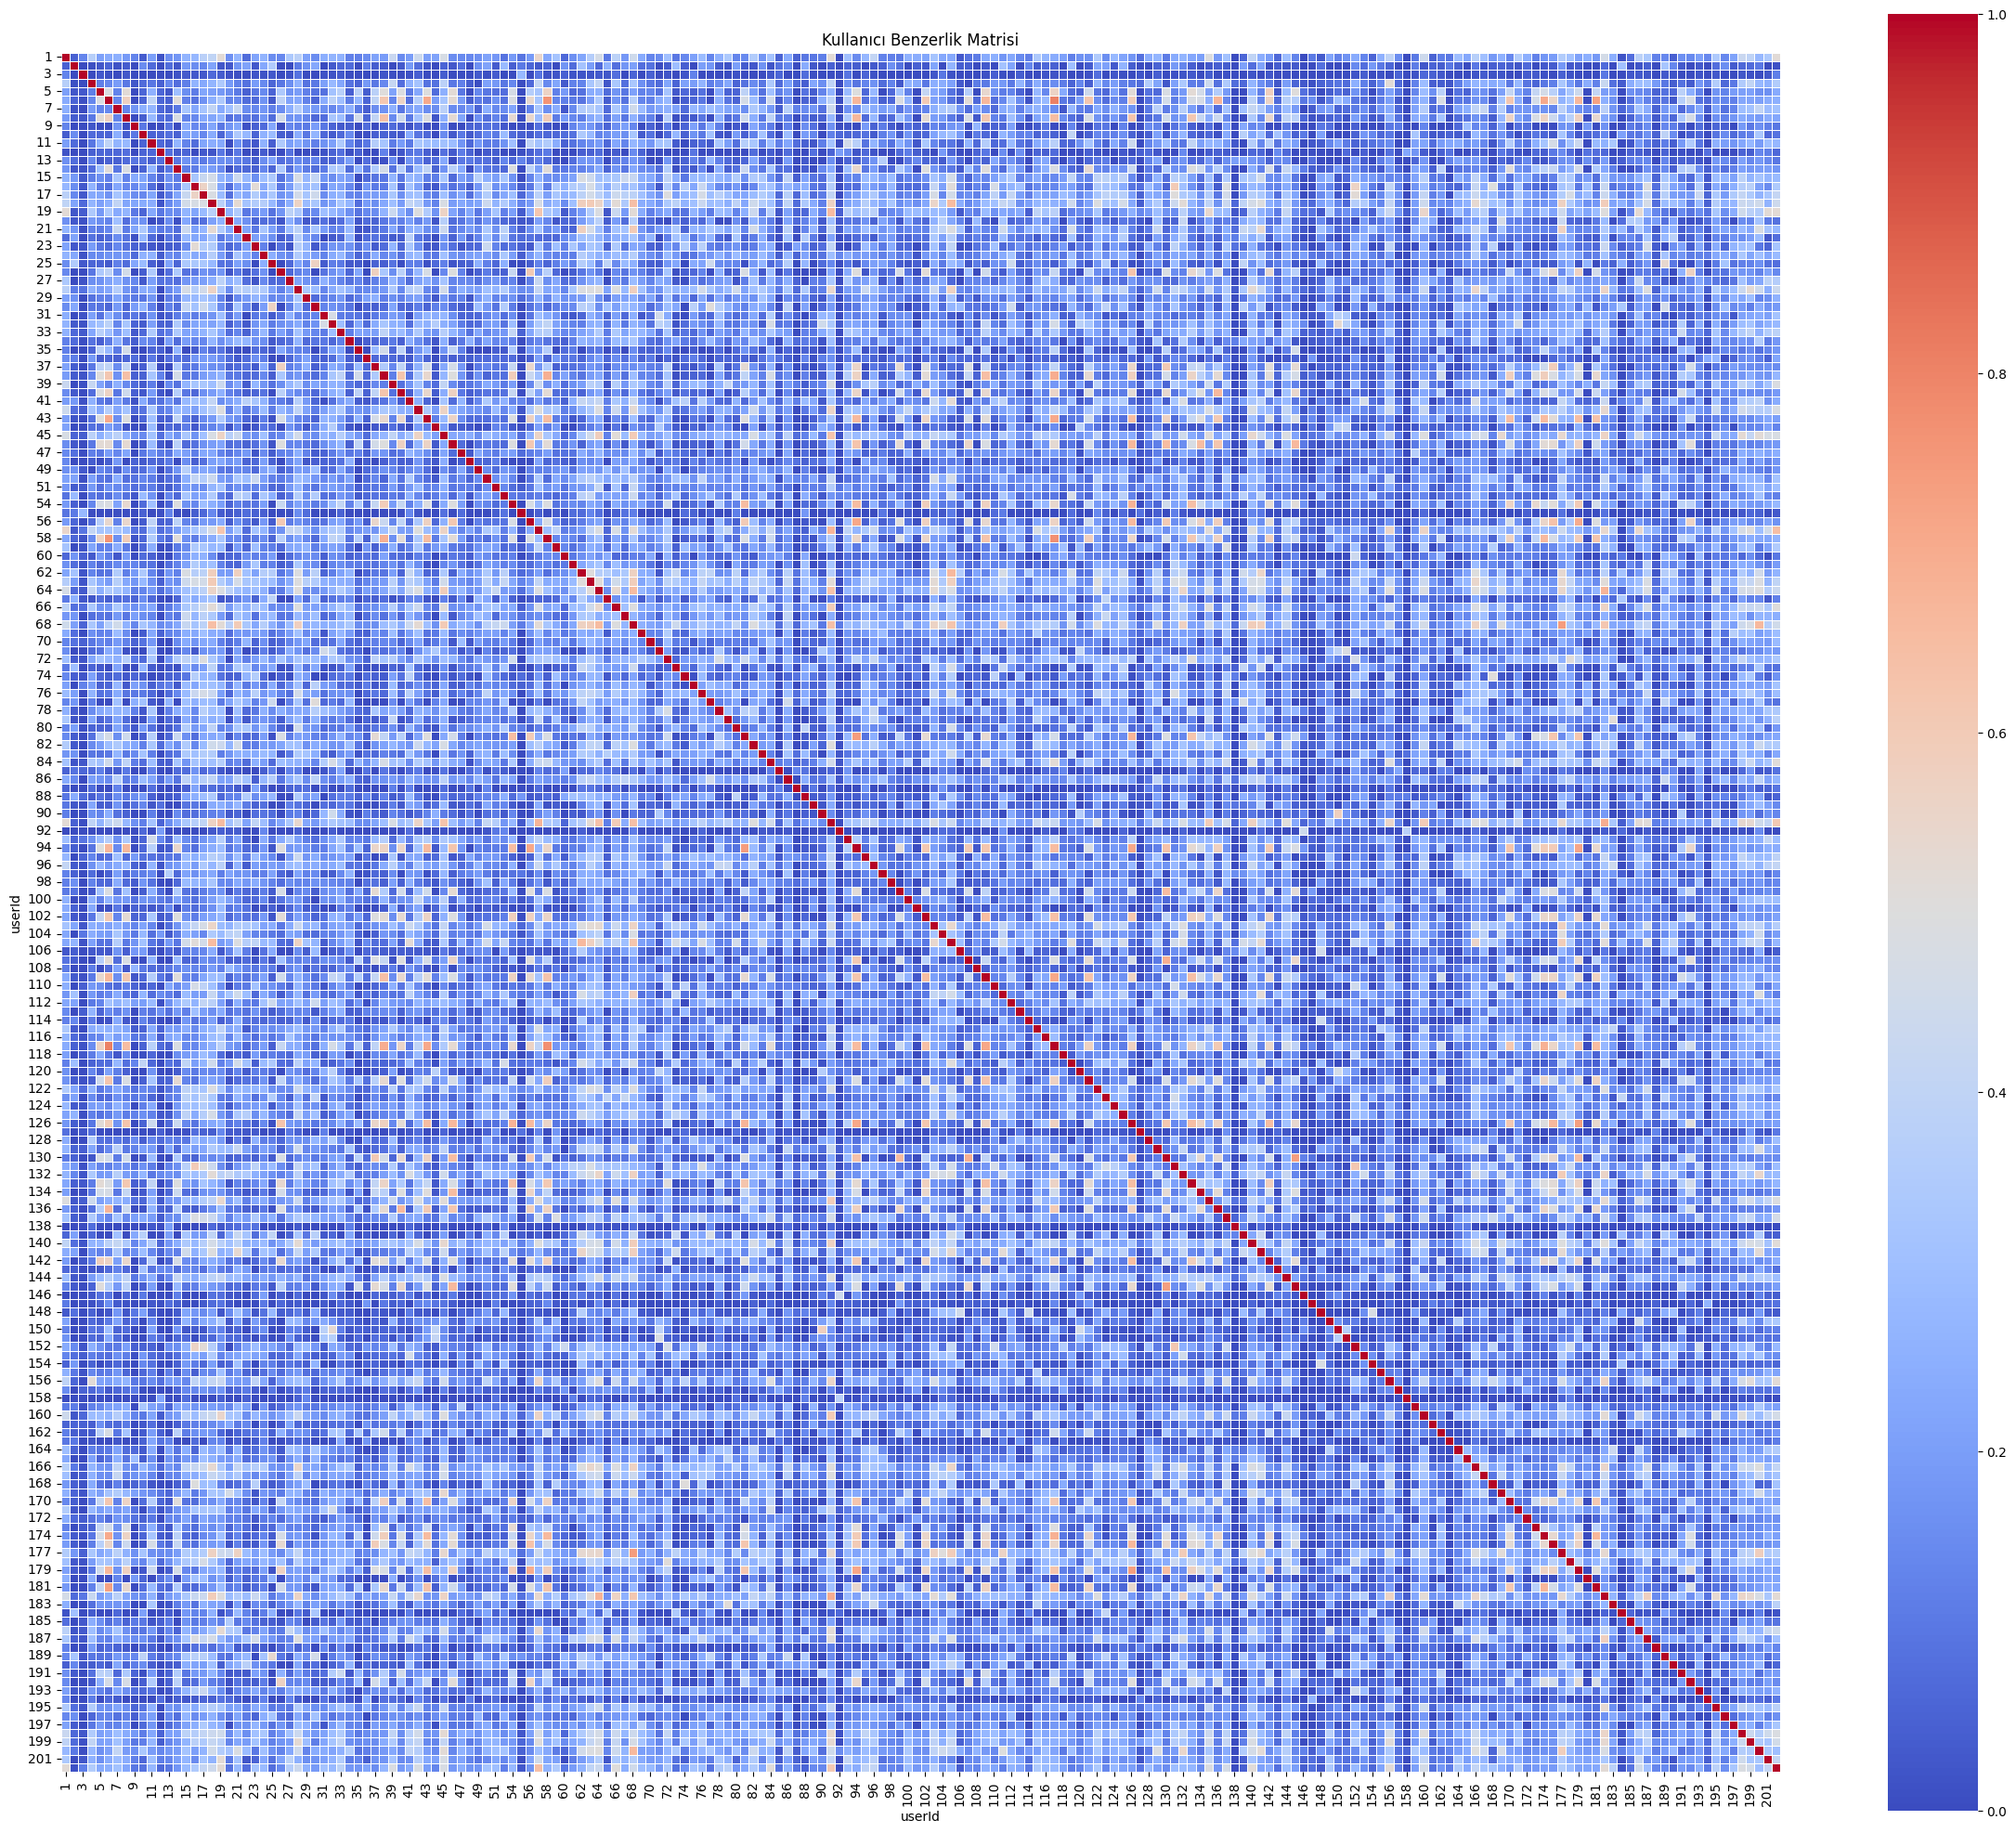

In [ ]:
plt.figure(figsize=(24,20))
sns.heatmap(user_sim_df.iloc[:200,:200],
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=.5)
plt.title('Kullanıcı Benzerlik Matrisi')
plt.tight_layout()
plt.show()

In [ ]:
def user_based_recommend(user_id,n=5):
    """
    Kullanıcı tabanlı işbirlikçi filtreleme
    """
    if user_id not in user_movie_matrix.index:
        print(f"'{user_id}' bulunamadı!")
        return None
    #Kullancının izlemediği filmler
    unwatched=user_movie_matrix.loc[user_id][user_movie_matrix.loc[user_id].isna()].index
    if len(unwatched)==0:
        print(f"{user_id} tüm filmleri izlemiş!")
        return None
    #benzer izleyicileri bul
    user_similirities=user_sim_df[user_id].drop(user_id).sort_values(ascending=False)
    top_similar_users=user_similirities.head(n).index

    #Benzer izleyici puanlarını ağırlık ortalama ile hesaplayacağız
    predicted_scores={}
    for film in unwatched:
        weighted_sum=0
        similarity_sum=0
        for sim_user in top_similar_users:
            rating=user_movie_matrix.loc[sim_user,film]
            if not np.isnan(rating):
                sim=user_sim_df.loc[user_id,sim_user]
                weighted_sum+=sim*rating
                similarity_sum+=sim
        if similarity_sum>0:
            predicted_scores[film]=weighted_sum/similarity_sum
    #en yüksek puan tahmini olan filmleri
    recommendations=pd.Series(predicted_scores).sort_values(ascending=False).head(n)
    return recommendations


In [ ]:
user_based_recommend(1,n=10)

,0
12 Angry Men (1957),5.000000
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),5.000000
"Godfather, The (1972)",4.853451
"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",4.757944
Annie Hall (1977),4.662703
Chinatown (1974),4.622625
Blade Runner (1982),4.616826
Brazil (1985),4.500578
Big Fish (2003),4.500000
Blood Diamond (2006),4.500000


Seçilen kullanıcının en beğendiği filmler

In [ ]:
ratings_filled.loc[60].sort_values(ascending=False)

,60
title,
"Godfather, The (1972)",5.0
Schindler's List (1993),5.0
"Dark Knight, The (2008)",5.0
City of God (Cidade de Deus) (2002),4.0
"Shawshank Redemption, The (1994)",4.0
...,...
Fargo (1996),0.0
Fantasia (1940),0.0
Face/Off (1997),0.0


In [ ]:
user_based_recommend(60,n=10)

,0
"40-Year-Old Virgin, The (2005)",5.0
Aladdin (1992),5.0
Apocalypse Now (1979),5.0
"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",5.0
Batman Begins (2005),5.0
"Dark Knight Rises, The (2012)",5.0
Vertigo (1958),5.0
Léon: The Professional (a.k.a. The Professional) (Léon) (1994),5.0
Iron Man (2008),5.0
"Lion King, The (1994)",5.0


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. En çok oy alan (count) ilk 500 filmi belirleyelim
top_500_movie_ids = df['movieId'].value_counts().head(500).index
df_popular_500 = df[df['movieId'].isin(top_500_movie_ids)]

# 2. Matrisi ve tür bilgilerini hazırlayalım
user_movie_matrix_500 = df_popular_500.pivot_table(index='userId', columns='title', values='rating')
ratings_filled_500 = user_movie_matrix_500.fillna(0)

# Filtreleme için film-tür eşleşmesini hazırlayalım
movie_genres = df_popular_500[['title', 'genres']].drop_duplicates().set_index('title')
unique_genres = sorted(list(set("|".join(df_popular_500['genres'].unique()).split("|"))))

# Mevcut kullanıcılar listesi
existing_user_ids = sorted(user_movie_matrix_500.index.tolist())

def get_new_user_recommendations(*args):
    movie_names = args[:20]
    ratings = args[20:40]
    selected_genres = args[40]
    new_user_ratings = pd.Series(0.0, index=user_movie_matrix_500.columns)
    for movie, rating in zip(movie_names, ratings):
        if movie and movie in new_user_ratings.index:
            new_user_ratings[movie] = float(rating)

    temp_matrix = ratings_filled_500.copy()
    new_user_id = "NEW_USER"
    temp_matrix.loc[new_user_id] = new_user_ratings
    sim_matrix = cosine_similarity(temp_matrix)
    sim_df = pd.DataFrame(sim_matrix, index=temp_matrix.index, columns=temp_matrix.index)
    similar_users = sim_df[new_user_id].drop(new_user_id).sort_values(ascending=False).head(10)

    predicted_scores = {}
    unwatched = new_user_ratings[new_user_ratings == 0].index
    for film in unwatched:
        weighted_sum = 0
        sim_sum = 0
        for sim_user, score in similar_users.items():
            user_rating = ratings_filled_500.loc[sim_user, film]
            if user_rating > 0:
                weighted_sum += score * user_rating
                sim_sum += score
        if sim_sum > 0: predicted_scores[film] = weighted_sum / sim_sum

    if not predicted_scores: return pd.DataFrame([["Yeterli veri yok", "-"]], columns=["Önerilen Film", "Türler"])
    res_df = pd.Series(predicted_scores).sort_values(ascending=False).reset_index()
    res_df.columns = ["Önerilen Film", "Skor"]
    res_df = res_df.merge(movie_genres, left_on="Önerilen Film", right_index=True)
    if selected_genres:
        res_df = res_df[res_df['genres'].apply(lambda x: all(g in x.split('|') for g in selected_genres))]
    return res_df[["Önerilen Film", "genres", "Skor"]].head(10).rename(columns={"genres": "Türler"})

def get_existing_user_info(user_id):
    # Kullanıcının en yüksek puan verdiği 20 film
    user_ratings = user_movie_matrix_500.loc[user_id].dropna().sort_values(ascending=False).head(20).reset_index()
    user_ratings.columns = ["Film Adı", "Puan"]
    # Kullanıcıya özel öneriler
    recommendations = user_based_recommend(user_id, n=10)
    if recommendations is not None:
        rec_df = recommendations.reset_index()
        rec_df.columns = ["Önerilen Film", "Tahmini Skor"]
        return user_ratings, rec_df
    return user_ratings, pd.DataFrame([["Öneri oluşturulamadı", 0]], columns=["Önerilen Film", "Tahmini Skor"])

popular_list_500 = sorted(user_movie_matrix_500.columns.tolist())

with gr.Blocks() as demo:
    gr.Markdown("# 🎬 Gelişmiş Film Keşif Portalı")

    with gr.Tabs():
        with gr.TabItem("Yeni Kullanıcı Önerisi"):
            with gr.Row():
                with gr.Column(scale=3):
                    gr.Markdown("### 1. Puanlarını Gir")
                    movie_inputs = []
                    rating_inputs = []
                    for col in range(4):
                        with gr.Row():
                            for row in range(5):
                                with gr.Column(min_width=150):
                                    m = gr.Dropdown(popular_list_500, label="Film", filterable=True)
                                    r = gr.Slider(0, 5, step=0.5, value=0, label="Puan")
                                    movie_inputs.append(m)
                                    rating_inputs.append(r)
                with gr.Column(scale=1):
                    gr.Markdown("### 2. Filtrele")
                    genre_filter = gr.Dropdown(choices=unique_genres, label="Türler", multiselect=True)
                    btn_new = gr.Button("Önerileri Getir", variant="primary")
            output_new = gr.Dataframe(label="Öneriler", row_count=10)
            btn_new.click(fn=get_new_user_recommendations, inputs=movie_inputs + rating_inputs + [genre_filter], outputs=output_new)

        with gr.TabItem("Mevcut Kullanıcı Analizi"):
            gr.Markdown("### Kayıtlı Bir Kullanıcıyı İncele")
            user_id_input = gr.Dropdown(choices=existing_user_ids, label="Kullanıcı ID Seç")
            with gr.Row():
                with gr.Column():
                    gr.Markdown("**Kullanıcının En Sevdiği Filmler (Top 20)**")
                    fav_output = gr.Dataframe(row_count=20)
                with gr.Column():
                    gr.Markdown("**Bu Kullanıcı İçin Yeni Öneriler**")
                    rec_output = gr.Dataframe(row_count=10)
            user_id_input.change(fn=get_existing_user_info, inputs=user_id_input, outputs=[fav_output, rec_output])

demo.launch(debug=True)

NameError: name 'df' is not defined